# Environment Setup

In [1]:
import torch
from torch import nn
from transformers import T5ForConditionalGeneration, T5TokenizerFast, AdamW
from datasets import load_dataset, ClassLabel
from torch.utils.data import DataLoader
from accelerate import Accelerator
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
import os
import time
from tqdm import tqdm
import seaborn as sns
from adapters import AutoAdapterModel, AdapterConfig
from peft import get_peft_model, LoraConfig, TaskType

In [2]:
os.environ['HF_HOME'] = '/DATA9/suyamoon/.cache/HuggingFace'
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
DEVICE = torch.device("cuda:0")

# Configuration constants

In [3]:
PEFT_CONFIG = {
    "soft_prompt": {
        "save_prefix": "soft_prompt_metrics"
    },
    "adapter": {
        "save_prefix": "adapter_metrics"
    },
    "lora": {
        "save_prefix": "lora_metrics" 
    }
}

DATASET_CONFIG = {
    "max_length": 512,
    "batch_size": 32,
    "epochs": 5
}

MODEL_NAME = "t5-small"

# Helper Functions

In [4]:
def load_imdb(method):
    dataset = load_dataset('imdb', cache_dir='/DATA9/suyamoon/.cache/HuggingFace')
    dataset = dataset.cast_column('label', ClassLabel(names=['neg', 'pos']))
    
    return dataset

def prepare_data(method):
    tokenizer = T5TokenizerFast.from_pretrained(MODEL_NAME)
    
    def tokenize_function(examples):
        return tokenizer(
            examples['text'],
            max_length=DATASET_CONFIG['max_length'],
            padding='max_length',
            truncation=True
        )
    
    dataset = load_imdb(method).map(tokenize_function, batched=True)
    dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
    
    train_val = dataset['train'].train_test_split(test_size=0.1, shuffle=False)
    test_set = dataset['test']
    
    train_loader = DataLoader(
        train_val['train'], 
        batch_size=DATASET_CONFIG['batch_size'], 
        shuffle=True
    )
    
    val_loader = DataLoader(
        train_val['test'], 
        batch_size=DATASET_CONFIG['batch_size'] * 2
    )
    
    test_loader = DataLoader(
        test_set, 
        batch_size=DATASET_CONFIG['batch_size'] * 2
    )
    
    return train_loader, val_loader, test_loader


In [5]:
def train_one_epoch(model, optimizer, train_loader, accelerator, loss_fn):
    model.train()
    total_loss = 0
    start_time = time.time()
    
    for batch in tqdm(train_loader, desc="Training"):
        outputs = model(batch['input_ids'], batch['attention_mask'])
        loss = loss_fn(outputs, batch['label'].to(outputs.device))
        
        accelerator.backward(loss)
                
        optimizer.step()
        optimizer.zero_grad()
        
        total_loss += loss.item()
    
    epoch_time = time.time() - start_time
    return total_loss / len(train_loader), epoch_time


def compute_metrics(logits, labels):
    labels = labels.to(logits.device)
    preds = torch.argmax(logits, dim=-1)
    acc = (preds == labels).float().mean().item()
    return {'accuracy': acc}

def evaluate(model, val_loader, loss_fn):
    model.eval()
    all_logits = []
    all_labels = []
    total_loss = 0
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Evaluating"):
            outputs = model(batch['input_ids'], batch['attention_mask'])
            loss = loss_fn(outputs, batch['label'].to(outputs.device))

            total_loss += loss.item()
            all_logits.append(outputs.cpu())
            all_labels.append(batch['label'].cpu())  # Ensure CPU for concatenation
    
    avg_loss = total_loss / len(val_loader)
    logits = torch.cat(all_logits, dim=0)
    labels = torch.cat(all_labels, dim=0)
    metrics = compute_metrics(logits, labels)
    
    return avg_loss, metrics, logits, labels


In [6]:
def plot_and_save(train_losses, val_losses, logits, labels, method):
    save_prefix = PEFT_CONFIG[method]["save_prefix"]
    preds = torch.argmax(logits, dim=-1).numpy()
    labels_np = labels.numpy()
    
    cm = confusion_matrix(labels_np, preds)
    
    probs = torch.softmax(logits, dim=1)[:, 1].numpy()
    fpr, tpr, _ = roc_curve(labels_np, probs)
    roc_auc = auc(fpr, tpr)
    
    precision, recall, _ = precision_recall_curve(labels_np, probs)
    ap_score = average_precision_score(labels_np, probs)
    
    plt.figure(figsize=(12, 10))
    
    # Loss curve
    plt.subplot(2, 2, 1)
    plt.plot(train_losses, marker='o', color='teal', label='Train')
    if val_losses:
        plt.plot(val_losses, marker='s', color='orange', label='Validation')
    plt.title('Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    # Confusion Matrix 
    plt.subplot(2, 2, 2)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=[0, 1], yticklabels=[0, 1])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    
    # ROC Curve
    plt.subplot(2, 2, 3)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    
    # Precision-Recall Curve
    plt.subplot(2, 2, 4)
    plt.plot(recall, precision, color='blue', lw=2, label=f'AP = {ap_score:.2f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc='lower left')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{save_prefix}.png")
    plt.show()
    
    return cm, roc_auc, ap_score

def print_detailed_metrics(metrics, cm, roc_auc, ap_score, final_train_time, model, method):
    print("\n" + "="*50)
    print(f"{method.upper()} TUNING RESULTS")
    print("="*50)
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"Average Precision: {ap_score:.4f}")
    print(f"Confusion Matrix:")
    print(cm)
    print(f"Training Time: {final_train_time:.2f} seconds")
    
    # Parameter efficiency analysis
    if hasattr(model, 'base_model'):
        total_params = sum(p.numel() for p in model.base_model.parameters())
    else:
        # Handle models without explicit base_model attribute
        total_params = sum(p.numel() for p in model.parameters())
    
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    efficiency = (1 - trainable_params/total_params) * 100
    
    print(f"Total Parameters: {total_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}")
    print(f"Parameter Efficiency: {efficiency:.2f}%")
    print("="*50)


In [7]:
def train_and_evaluate(model, optimizer, method):
    train_loader, val_loader, test_loader = prepare_data(method)
    
    loss_fn = nn.CrossEntropyLoss()
    
    accelerator = Accelerator(mixed_precision='fp16')
    model, optimizer, train_loader, val_loader = accelerator.prepare(
        model, optimizer, train_loader, val_loader
    )
    
    train_losses = []
    val_losses = []
    best_val_acc = 0
    total_train_time = 0
    
    for epoch in range(1, DATASET_CONFIG['epochs']+1):
        train_loss, epoch_time = train_one_epoch(model, optimizer, train_loader, accelerator, loss_fn)
        total_train_time += epoch_time
        train_losses.append(train_loss)
        
        val_loss, val_metrics, val_logits, val_labels = evaluate(model, val_loader, loss_fn)
        val_losses.append(val_loss)
        
        print(f"Epoch {epoch}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}, "
              f"Val Acc = {val_metrics['accuracy']:.4f}, Time = {epoch_time:.2f}s")
        
        if val_metrics['accuracy'] > best_val_acc:
            best_val_acc = val_metrics['accuracy']
            torch.save(model.state_dict(), f"best_{method}_model.pt")
    
    print("\nFinal Evaluation on Test Set:")
    test_loss, test_metrics, test_logits, test_labels = evaluate(model, test_loader, loss_fn)
    
    cm, roc_auc, ap_score = plot_and_save(train_losses, val_losses, test_logits, test_labels, method)
    
    print_detailed_metrics(test_metrics, cm, roc_auc, ap_score, total_train_time, model, method)
    
    return model, test_metrics


# Soft-Prompt Tuning

In [8]:
class SoftPromptT5(nn.Module):
    def __init__(self, model_name=MODEL_NAME, prompt_length=20):
        super().__init__()
        self.prompt_length = prompt_length
        self.base_model = T5ForConditionalGeneration.from_pretrained(model_name).to(DEVICE)
        self.base_model.requires_grad_(False)  # Freeze the base model
        
        # Initialize soft prompts (match T5's d_model=512)
        self.prompt_embeddings = nn.Embedding(prompt_length, 512).to(DEVICE)
        nn.init.normal_(self.prompt_embeddings.weight, std=0.02)  # start the weights as random small initial weights; from Prefix-Tuning paper
        
        # Classification head
        self.classifier = nn.Linear(512, 2).to(DEVICE)

    def forward(self, input_ids, attention_mask):
        input_ids = input_ids.to(DEVICE)
        attention_mask = attention_mask.to(DEVICE)
        
        inputs_embeds = self.base_model.shared(input_ids)
        
        prompt_indices = torch.arange(self.prompt_length, device=DEVICE)
        prompt_indices = prompt_indices.unsqueeze(0).expand(input_ids.size(0), -1)
        
        prompt_embeds = self.prompt_embeddings(prompt_indices)
        inputs_embeds = torch.cat([prompt_embeds, inputs_embeds], dim=1)
        
        prompt_mask = torch.ones(input_ids.size(0), self.prompt_length, device=DEVICE)
        attention_mask = torch.cat([prompt_mask, attention_mask], dim=1)
        
        outputs = self.base_model.encoder(
            inputs_embeds=inputs_embeds,
            attention_mask=attention_mask
        )
        
        pooled = outputs.last_hidden_state[:, 0, :]
        return self.classifier(pooled)

/home/suyamoon/data/miniconda3/envs/argmining/lib/python3.12/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
Evaluating: 100%|██████████| 40/40 [00:04<00:00,  8.28it/s]


Epoch 1: Train Loss = 0.6866, Val Loss = 0.9488, Val Acc = 0.0000, Time = 102.25s


Evaluating: 100%|██████████| 40/40 [00:04<00:00,  8.32it/s]


Epoch 2: Train Loss = 0.6050, Val Loss = 0.5883, Val Acc = 0.7148, Time = 101.32s


Evaluating: 100%|██████████| 40/40 [00:04<00:00,  8.32it/s]


...

Evaluating: 100%|██████████| 40/40 [00:04<00:00,  8.27it/s]


Epoch 4: Train Loss = 0.4591, Val Loss = 0.4645, Val Acc = 0.7820, Time = 101.85s


Evaluating: 100%|██████████| 40/40 [00:04<00:00,  8.20it/s]


Epoch 5: Train Loss = 0.4501, Val Loss = 0.4063, Val Acc = 0.8164, Time = 101.56s

Final Evaluation on Test Set:


Evaluating: 100%|██████████| 391/391 [00:48<00:00,  8.08it/s]


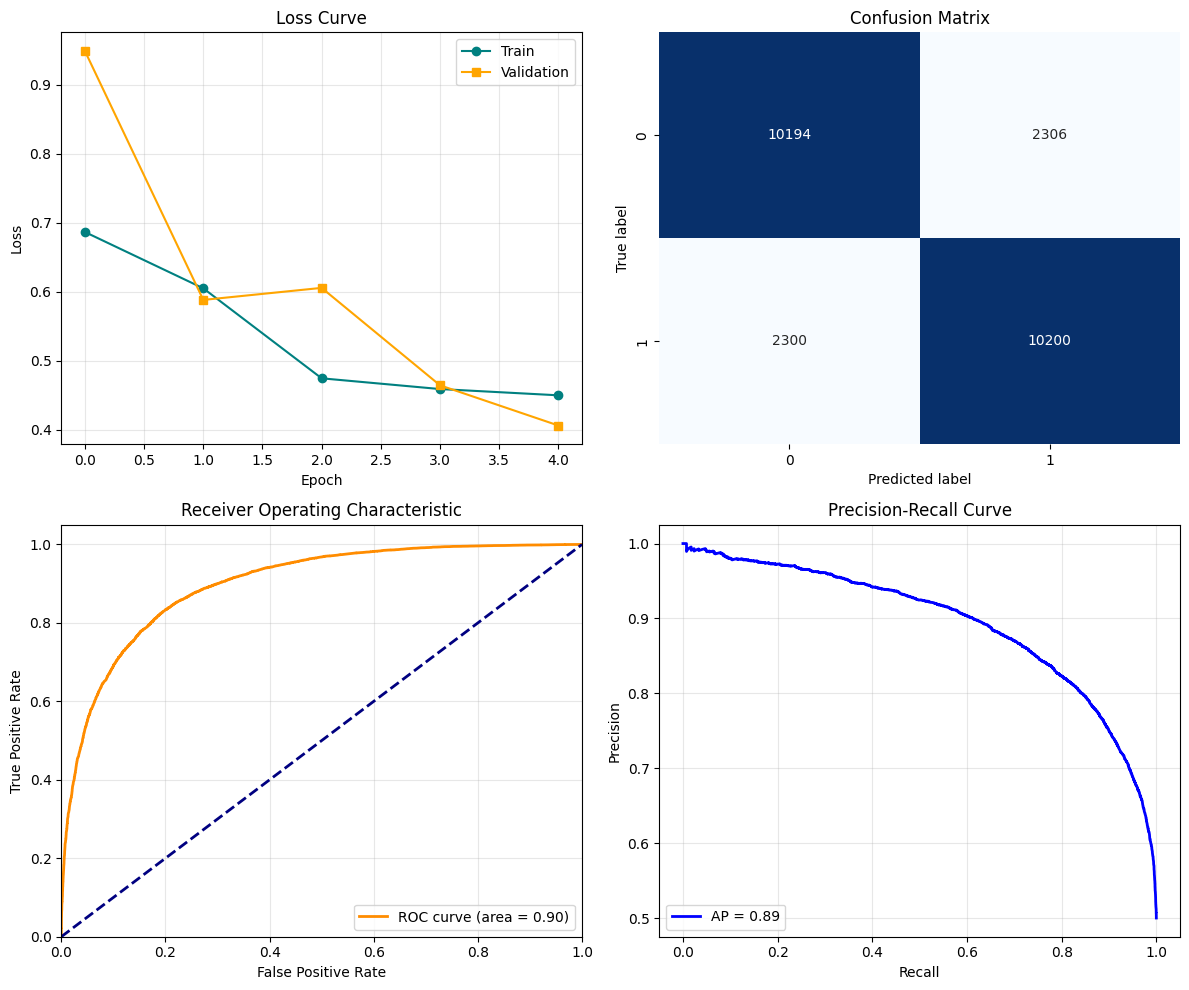


SOFT_PROMPT TUNING RESULTS
Accuracy: 0.8158
ROC AUC: 0.8976
Average Precision: 0.8939
Confusion Matrix:
[[10194  2306]
 [ 2300 10200]]
Training Time: 508.71 seconds
Total Parameters: 60,506,624
Trainable Parameters: 11,266
Parameter Efficiency: 99.98%


In [9]:
soft_prompt_model = SoftPromptT5()
soft_prompt_optimizer = AdamW([
    {'params': soft_prompt_model.prompt_embeddings.parameters()},
    {'params': soft_prompt_model.classifier.parameters()}
], lr=3e-4, weight_decay=0.01)
soft_prompt_finetuned_model, soft_prompt_test_metrics = train_and_evaluate(soft_prompt_model, soft_prompt_optimizer, method="soft_prompt")

# Questions for Analysis

<b>1. What are the advantages of soft-prompt tuning over full fine-tuning in terms of computational efficiency? Can we quantatively show, how much improvement do we obtain in terms of compute? </b> <br>
Soft-prompt saves a lot of time and compute by training only a small set of additional prompt embeddings. In full-finetuning, all the parameters are updated, which certainly takes longer time, and compute. <br><br>
I have quantitatively shown in the results that in this case, the total parameters of the model is 60,506,624 and the trainable parameter is only 11,266 which make the soft-prompt tuning method 99.98% efficient.
<br>
<br>
<br>
<b>2. How does the performance of soft-prompt tuning compare to manually crafted prompts?</b><br>
First of all, manually crafting prompts is a tough job, and not everyone knows how to do it. If anyone even does it, soft-prompt would still outperform the manual prompts because it specifically learns task-specific embeddings directly from the data. So, rather than relying on human intuition, or language for that sake, tuning the prompts based on data makes more sense, and is better performing too.
<br>
<br>
<br>
<b>3. What challenges did you encounter while implementing soft-prompt tuning, and how did you address them? Can you come up with a better strategy to improve soft-prompt tuning?</b><br>
I spent most of my time solving the dependency errors! Specifically some apis from accelerate have been deprecated, so I had to manually read the updated docs, find the correct implementation, and work with them. Also, choosing the perfect number of embeddings for soft-prompting was a tedious job. I tried multiple runs, and finally decided to read the paper "The Power of Scale for Parameter-Efficient Prompt Tuning" paper by Lester et al to understand that the optimal number is 20-30. So, decided to go with 20 for my experiment too.
<br><br>
Right now in the above experiment, i initialized random weights coming from gaussian distribution with s.d. 0.2. To improve soft-prompt tuning, we can initialize the soft-prompts with embeddings from relevant task-specific words. Also, curriculum learning is proven to be efficient- start with shorter prompts, and gradually increase the length as needed.
<br>
<br>
<br>
<b>4. How does the number of soft prompt tokens affect model performance? Can too many or too few prompt tokens degrade performance? What would be the optimal range of tokens to use for soft prompt tuning in the above experiment?</b><br>
Too few prompt tokens may lack the capacity to encode sufficient task information, and can underfit whereas, too many tokens can dilute the signal and overfit. So, the optimal range would be 20-30 for bigger models, and 5-20 for smaller models like t5. This has been thoroughly researched on "The Power of Scale for Parameter-Efficient Prompt Tuning" paper by Lester et al. In their paper, they have shown the soft-prompt with 20 tokens has outperformed others, so I also used 20 for my experiment. <br>
<br>
<br>
<b> 5. What happens if the soft prompts are initialized with random embeddings versus meaningful embeddings (e.g., derived from task-specific words)?</b><br>
Random initialization is standard and works, like what i did with my experiment. But, initializing with meaningful embeddings can speed up convergence and also improve performance sometimes because the prompts start closer to a useful region in the embedding space. <br>

# Adapter-Based Fine-Tuning

In [10]:
class AdapterT5(nn.Module):
    def __init__(self, model_name=MODEL_NAME):
        super().__init__()
        self.base_model = AutoAdapterModel.from_pretrained(model_name).to(DEVICE)
        self.base_model.freeze_model(True)

        adapter_config = AdapterConfig.load("houlsby", reduction_factor=4, dropout=0.1)

        self.base_model.add_adapter("imdb_adapter", config=adapter_config)
        self.base_model.train_adapter("imdb_adapter")
        self.base_model.set_active_adapters("imdb_adapter")
        
        self.classifier = nn.Linear(512, 2).to(DEVICE)

    def forward(self, input_ids, attention_mask):
        input_ids = input_ids.to(DEVICE)
        attention_mask = attention_mask.to(DEVICE)
        outputs = self.base_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True
        )
        encoder_hidden = outputs.encoder_hidden_states[-1]
        pooled = encoder_hidden[:, 0, :]
        return self.classifier(pooled)

/home/suyamoon/data/miniconda3/envs/argmining/lib/python3.12/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
Evaluating: 100%|██████████| 40/40 [00:12<00:00,  3.28it/s]


Epoch 1: Train Loss = 0.6835, Val Loss = 0.7975, Val Acc = 0.1468, Time = 174.59s


Evaluating: 100%|██████████| 40/40 [00:12<00:00,  3.29it/s]


Epoch 2: Train Loss = 0.5689, Val Loss = 0.3693, Val Acc = 0.8432, Time = 175.01s


Evaluating: 100%|██████████| 40/40 [00:12<00:00,  3.29it/s]


...

Evaluating: 100%|██████████| 40/40 [00:12<00:00,  3.29it/s]


Epoch 4: Train Loss = 0.3225, Val Loss = 0.3725, Val Acc = 0.8396, Time = 174.95s


Evaluating: 100%|██████████| 40/40 [00:12<00:00,  3.29it/s]


Epoch 5: Train Loss = 0.2962, Val Loss = 0.3140, Val Acc = 0.8748, Time = 174.58s

Final Evaluation on Test Set:


Evaluating: 100%|██████████| 391/391 [02:01<00:00,  3.22it/s]


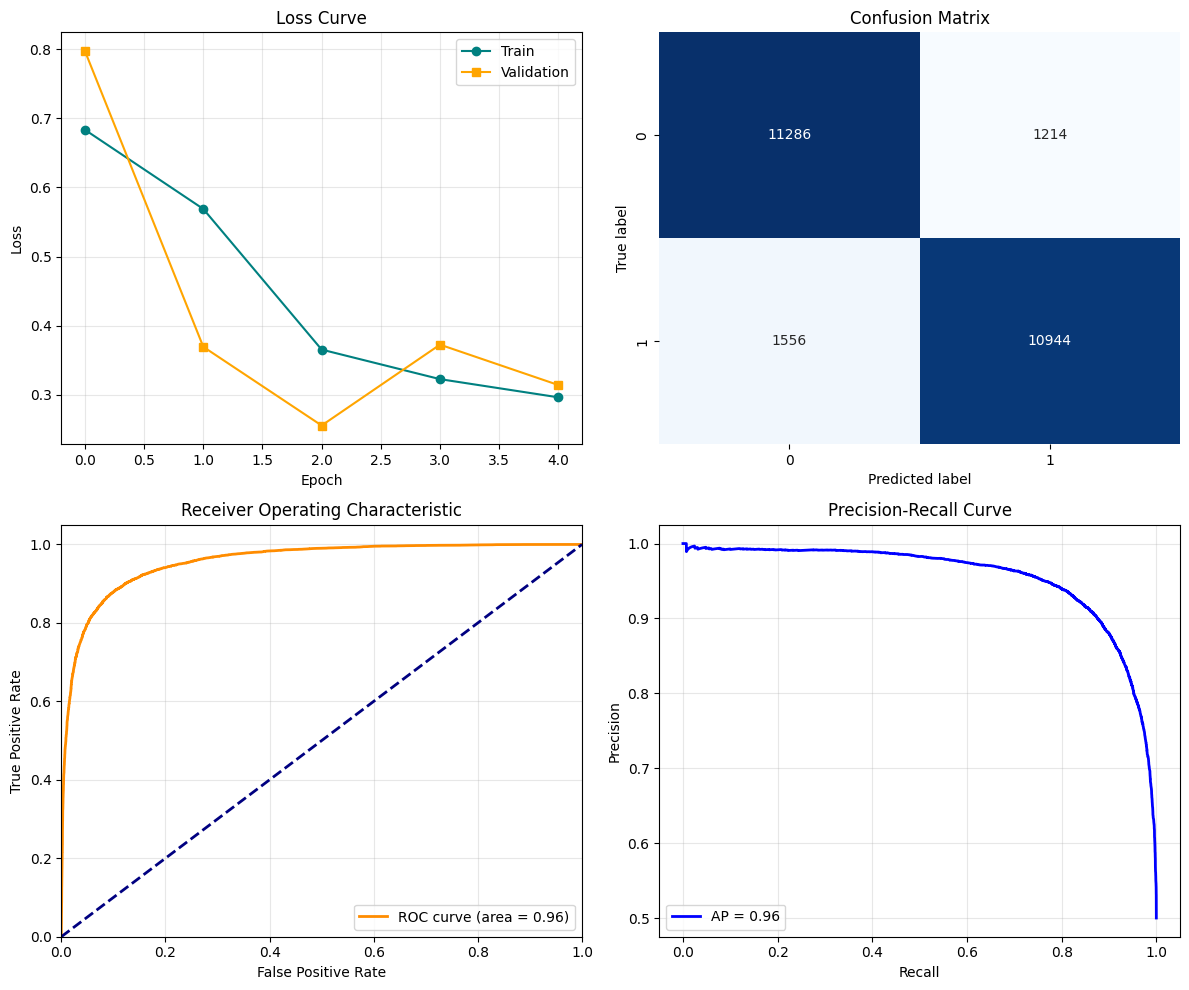


ADAPTER TUNING RESULTS
Accuracy: 0.8892
ROC AUC: 0.9562
Average Precision: 0.9557
Confusion Matrix:
[[11286  1214]
 [ 1556 10944]]
Training Time: 873.88 seconds
Total Parameters: 63,667,712
Trainable Parameters: 3,162,114
Parameter Efficiency: 95.03%


In [11]:
adapter_model = AdapterT5()

adapter_optimizer = AdamW(
    adapter_model.parameters(), 
    lr=2e-5,
    weight_decay=0.01
)

adapter_finetuned_model, adapter_test_metrics = train_and_evaluate(
    adapter_model, 
    adapter_optimizer, 
    method="adapter"
)

# Questions for Analysis



<b>1. How does the computational efficiency of adapter-based fine-tuning compare to soft-prompt tuning?</b><br>
Adapter-based fine tuning is less efficient than soft-prompt tuning (in our case 99.98% vs 95.03%). The trainable parameters for adapter based tuning were 3,162,114 and for soft-prompt tuning, it was just 11,266. 
<br><br><br>

<b>2. What challenges did you face while implementing adapters, and how did you overcome them?</b><br>
Finding the correct configuration for adapter was a hassle. I first tried with pfeiffer, it was giving me nan values for train and val loss for some reason. Later, I chose to go with the most popular config- houlsby, and it solved the issue. Also, i first tried with the adapter-transformers library as given in the assignment, but i kept on getting run time errors, then i shifted to the adapters library.
<br><br><br>
<b>3. How does the size of the adapter module affect performance? Can larger adapters improve results significantly? Can we use adapters that have more number of parameters when compared to original model? What advantage/disadvantage would it add?</b><br>
Larger adapters can improve the task performance specially on complex tasks. But it comes with a cost of increased computation. <br>
Adapters should remain much smaller than the original model to preserve efficiency. Using adapters larger than the base model itself is opposite of the whole parameter-efficiency theory, which can introduce overfitting.<br>
Optimal adapter size would typically be around 1-10% of the base model. Exceeding this range offers little benefit and increases the resource usage.
<br><br><br>


<b>4. Could adapter-based fine-tuning be applied to multilingual tasks? What modifications would be required?</b><br>
Yes adapter-based finetuning can be applied to multilingual tasks. Just separate adapters need to be trained for each language/task. Modifications can include language-specific adapters to combine the knowledge across languages. No major architectural changes are required, but a careful management of adapter selection and routing is required.
<br><br><br>


<b>5. How would you extend adapter-based fine-tuning to work with multimodal models (e.g., text and image inputs)?</b><br>
To support multimodal inputs, adapters can be inserted to both text and vision branches of the multimodal model. Adapters may need to be modality specific (eg. text adapters, image adapters) or use fusion adapters to combine information. 


# LoRA (Low-Rank Adaptation) Fine-Tuning

In [12]:
class LoRAT5Classifier(nn.Module):
    def __init__(self, model_name=MODEL_NAME, r=8, alpha=16, dropout=0.1):
        super().__init__()
        self.base_model = T5ForConditionalGeneration.from_pretrained(model_name).to(DEVICE)
        self.base_model.requires_grad_(False)  # Freeze the base model

        lora_config = LoraConfig(
            r=r,
            lora_alpha=alpha,
            target_modules=["q", "v"], 
            lora_dropout=dropout,
            bias="none",
            task_type=TaskType.SEQ_CLS
        )
        self.base_model = get_peft_model(self.base_model, lora_config)
        self.classifier = nn.Sequential(
            nn.LayerNorm(self.base_model.config.d_model).to(DEVICE),
            nn.Dropout(0.1).to(DEVICE),
            nn.Linear(self.base_model.config.d_model, 2).to(DEVICE)
        )

    def forward(self, input_ids, attention_mask):
        input_ids = input_ids.to(DEVICE)
        attention_mask = attention_mask.to(DEVICE)
        outputs = self.base_model.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        pooled = outputs.last_hidden_state[:, 0, :]
        return self.classifier(pooled)


/home/suyamoon/data/miniconda3/envs/argmining/lib/python3.12/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
Evaluating: 100%|██████████| 40/40 [00:04<00:00,  8.43it/s]


Epoch 1: Train Loss = 0.4354, Val Loss = 0.4173, Val Acc = 0.8284, Time = 102.90s


Evaluating: 100%|██████████| 40/40 [00:04<00:00,  8.44it/s]


Epoch 2: Train Loss = 0.2735, Val Loss = 0.3137, Val Acc = 0.8716, Time = 102.76s


Evaluating: 100%|██████████| 40/40 [00:04<00:00,  8.39it/s]


...

Evaluating: 100%|██████████| 40/40 [00:04<00:00,  8.44it/s]


Epoch 4: Train Loss = 0.2366, Val Loss = 0.2201, Val Acc = 0.9148, Time = 102.39s


Evaluating: 100%|██████████| 40/40 [00:04<00:00,  8.41it/s]


Epoch 5: Train Loss = 0.2253, Val Loss = 0.2818, Val Acc = 0.8892, Time = 103.08s

Final Evaluation on Test Set:


Evaluating: 100%|██████████| 391/391 [00:47<00:00,  8.20it/s]


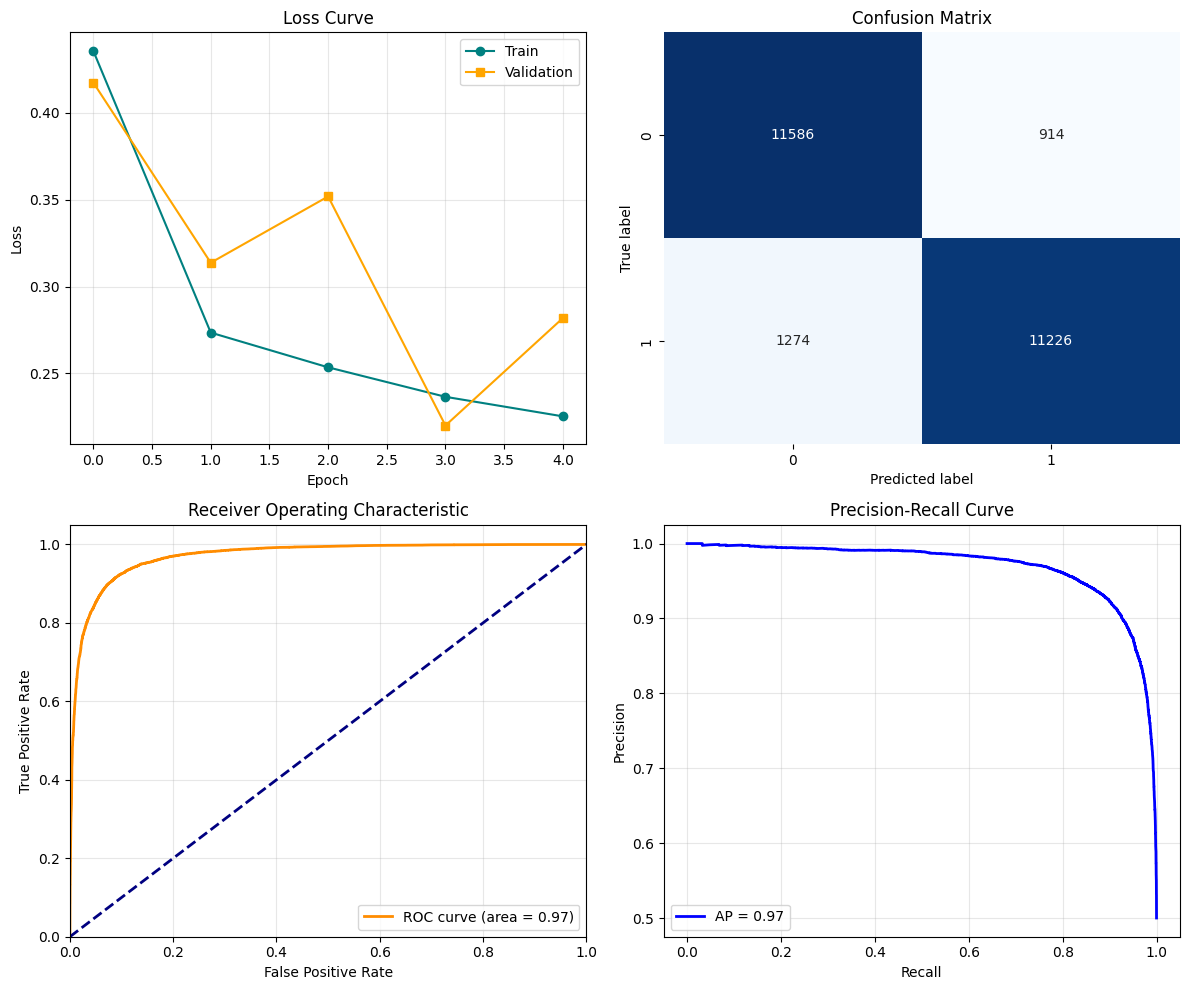


LORA TUNING RESULTS
Accuracy: 0.9125
ROC AUC: 0.9705
Average Precision: 0.9696
Confusion Matrix:
[[11586   914]
 [ 1274 11226]]
Training Time: 513.93 seconds
Total Parameters: 60,801,536
Trainable Parameters: 296,962
Parameter Efficiency: 99.51%


In [15]:
lora_model = LoRAT5Classifier(r=8)
lora_optimizer = AdamW(lora_model.parameters(), lr=3e-4, weight_decay=0.01)
lora_finetuned_model, lora_test_metrics = train_and_evaluate(lora_model, lora_optimizer, method="lora")


# Questions for Analysis

<b>1. How does the memory efficiency of LoRA compare to adapter-based fine-tuning and soft prompts?</b><br>
Soft-prompts have the smallest parameter count, then comes LoRa in the middle, and then finally adapter-based finetuning. Lora only takes 0.2-0.3% of the base model size, compared to adapters (1-10%), and soft prompts (with usually a few thousand parameters). <br><br><br>
<b>2. What challenges did you encounter while implementing LoRA, and how did you overcome them?</b><br>
Seleting the right layers and rank(r) to adapt for each task was tough. I tried with different r values (4,8, and 16), and 8 gave the highest accuracy, so I went with 8. 
<br><br><br>
<b>3. How does the choice of rank r affect the model’s accuracy and computational cost? What would be a suitable measure to choose the optimal rank for a specific task?</b><br>
Lower ranks (eg, r=4–8) are more efficient but may underfit complex tasks; higher ranks (e.g., r=32–256) increase capacity and accuracy but with higher memory and compute costs. We can follow practical heuristic to choose an optimal rank: start with r=8–16 for simple tasks, r=32–64 for complex tasks, and validate
<br><br><br>
<b>4. How does LoRA compare to other parameter-efficient fine-tuning methods like adapters in terms of scalability?</b><br>
LoRa scales amazingly to large models and many tasks because lora adapter is lightweight and can be loaded/unloaded quickly. It has low memory, so deployment of hundreds of task-specific adapters with a signle base model is possible.
<br><br><br>
<b>5. How would you extend LoRA to work with multimodal models (e.g., text and image inputs)?</b><br>
LoRa can be applied to multimodal models by inserting low-rank adapters into both text and vision branches. Just identify and adapt modality specific layers, and combine the information across modalities.

# Other Parameter-Efficient Fine-Tuning (PEFT) Approaches

Beyond Soft-Prompt Tuning, Adapter-Based Fine-Tuning, and LoRA, several notable PEFT methods have emerged. Each modifies model parameters or representations in a resource-efficient manner, often targeting specific subspaces or components of the model.

---

### 1. **Prefix Tuning**

**Concept:**  
Prefix tuning prepends a sequence of trainable vectors (prefixes) to the input of each transformer layer, influencing the model's hidden states throughout the network.

**Mathematical Formulation:**  
Given a transformer layer with input sequence `X`, prefix tuning optimizes a set of prefix vectors ` P ` (of length ` l `), which are concatenated to the hidden states:
$$
\text{Input to Layer} = [P; X]
$$
Only ` P ` is updated during training; the rest of the model remains frozen.

**Trade-offs:**  
- **Memory:** Very efficient; only prefix vectors are stored.
- **Compute:** Low, as only a small set of vectors is trained.
- **Adaptability:** Effective for many tasks, but may underperform on tasks requiring deeper model adaptation.

---

### 2. **P-Tuning (P-Tuning v2)**

**Concept:**  
P-Tuning generalizes prompt tuning by learning continuous prompt embeddings, often inserted at various layers, and sometimes combined with prefix tuning for deeper influence.

**Mathematical Formulation:**  
Let ` E ` be the embedding matrix and ` P ` be the trainable prompt embeddings:
$$
\text{Input Embeddings} = [P; E(X)]
$$
For P-Tuning v2, prompts can be inserted at multiple layers, not just the input.

**Trade-offs:**  
- **Memory:** Efficient; only prompt embeddings are trained.
- **Compute:** Slightly higher than prompt tuning if prompts are inserted at multiple layers.
- **Adaptability:** More flexible and effective than simple prompt tuning, especially for complex tasks.

---

### 3. **BitFit**

**Concept:**  
BitFit restricts fine-tuning to only the bias terms in the model’s linear layers.

**Mathematical Formulation:**  
For a linear layer $$ y = Wx + b $$, only ` b ` is updated:
$$
\min_{b} \mathcal{L}(y, \hat{y})
$$
where ` W ` is frozen.

**Trade-offs:**  
- **Memory:** Extremely efficient; only biases are trainable.
- **Compute:** Minimal.
- **Adaptability:** Works surprisingly well for some classification tasks, but limited capacity for complex adaptation.

---

### 4. **IA3 (Infused Adapter by Adding and Adjusting Attributes)**

**Concept:**  
IA3 introduces trainable scaling vectors (multiplicative adapters) into key locations (e.g., attention and feed-forward layers), modulating activations without adding full adapter modules.

**Mathematical Formulation:**  
Given an activation ` h `, IA3 applies a learned scaling vector ` a `:
$$
h' = a \odot h
$$
where `⦿` denotes element-wise multiplication and ` a ` is trained while the rest of the model is frozen.

**Trade-offs:**  
- **Memory:** Efficient; only scaling vectors are trained.
- **Compute:** Low.
- **Adaptability:** Good for tasks where scaling activations is sufficient; less expressive than full adapters.

---

### 5. **Diff Pruning**

**Concept:**  
Diff Pruning learns a sparse, task-specific difference ("delta") to the original model parameters.

**Mathematical Formulation:**  
Let ` θ ` be the original parameters, ` Δθ ` the learned sparse difference:
$$
\theta' = \theta + \Delta \theta
$$
where ` Δθ ` is regularized to be sparse.

**Trade-offs:**  
- **Memory:** Moderate; stores sparse deltas.
- **Compute:** Slightly higher due to sparsity constraints.
- **Adaptability:** Can closely match full fine-tuning performance if the task requires only small changes.

---


## Comparative Table

| Method        | Memory Usage    | Computational Efficiency | Adaptability         |
|---------------|----------------|-------------------------|----------------------|
| Prefix Tuning | Very Low       | Very High               | Moderate             |
| P-Tuning      | Low            | High                    | High                 |
| BitFit        | Extremely Low  | Extremely High          | Limited              |
| IA3           | Very Low       | Very High               | Good                 |
| Diff Pruning  | Moderate       | Moderate                | High                 |

---

## Most Suitable PEFT Method for Multilingual Text Classification with Limited Data

**Recommendation: LoRA or Adapters**

- **LoRA** is highly suitable for multilingual text classification with limited data due to its:
  - Excellent memory and compute efficiency.
  - Strong performance across languages, including unseen ones.
  - Scalability for multi-task and multi-language scenarios.
  - Proven effectiveness in multilingual and cross-lingual benchmarks, often matching or outperforming adapters and other PEFTs, especially for short-text classification.

- **Adapters** are also effective, particularly when modularity and task/language separation are needed. They are easy to manage for multi-task setups and allow for language-specific or task-specific modules.

### Comparative Justification

- **LoRA vs. Adapters:**  
  - LoRA generally achieves similar or better accuracy than adapters, especially in multilingual and cross-lingual settings, while using fewer trainable parameters and less memory.
  - LoRA is more scalable for large models and many tasks, as each LoRA module is lightweight.
  - Adapters offer more modularity but may incur slightly higher memory and compute costs.

- **Soft-Prompt/Prefix/P-Tuning:**  
  - While extremely efficient, these methods may underperform on complex multilingual tasks or when deep adaptation is required.

- **Real-World Constraints:**  
  - With limited hardware and scarce training data, LoRA provides the best balance of efficiency, accuracy, and adaptability for multilingual text classification.

---
